In [1]:
from google.colab import drive
import zipfile
import os

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:

# Define paths
zip_path = "/content/drive/My Drive/Pavements.zip"  # Change this
extract_path = "/content/unzipped_folder"  # Destination folder in Colab

# Create extraction directory
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List extracted files
print("Unzipping done! Extracted files:")
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))



Streaming output truncated to the last 5000 lines.
/content/unzipped_folder/Pavements/Non-cracked/032-22.jpg
/content/unzipped_folder/Pavements/Non-cracked/083-149.jpg
/content/unzipped_folder/Pavements/Non-cracked/002-128.jpg
/content/unzipped_folder/Pavements/Non-cracked/047-75.jpg
/content/unzipped_folder/Pavements/Non-cracked/077-180.jpg
/content/unzipped_folder/Pavements/Non-cracked/025-49.jpg
/content/unzipped_folder/Pavements/Non-cracked/030-220.jpg
/content/unzipped_folder/Pavements/Non-cracked/096-90.jpg
/content/unzipped_folder/Pavements/Non-cracked/013-93.jpg
/content/unzipped_folder/Pavements/Non-cracked/039-177.jpg
/content/unzipped_folder/Pavements/Non-cracked/050-131.jpg
/content/unzipped_folder/Pavements/Non-cracked/002-20.jpg
/content/unzipped_folder/Pavements/Non-cracked/006-127.jpg
/content/unzipped_folder/Pavements/Non-cracked/033-144.jpg
/content/unzipped_folder/Pavements/Non-cracked/013-160.jpg
/content/unzipped_folder/Pavements/Non-cracked/076-171.jpg
/content/un

Found 44875 images belonging to 4 classes.
Found 11217 images belonging to 4 classes.


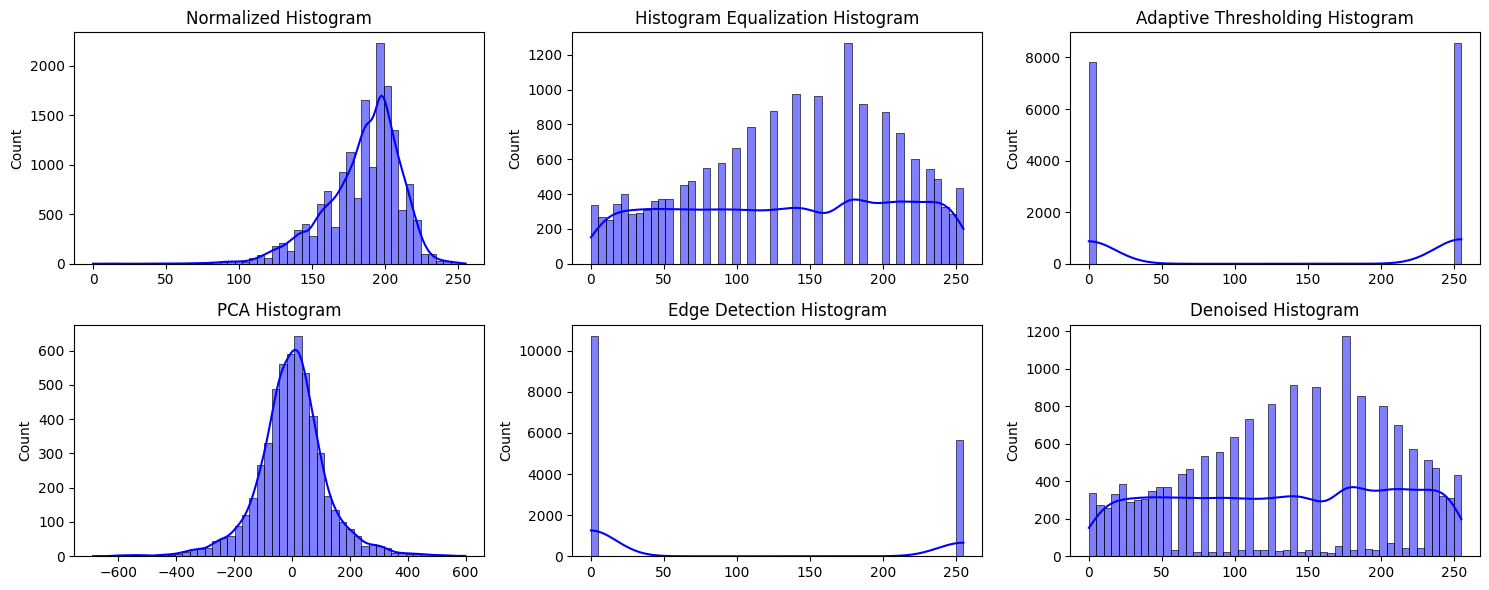

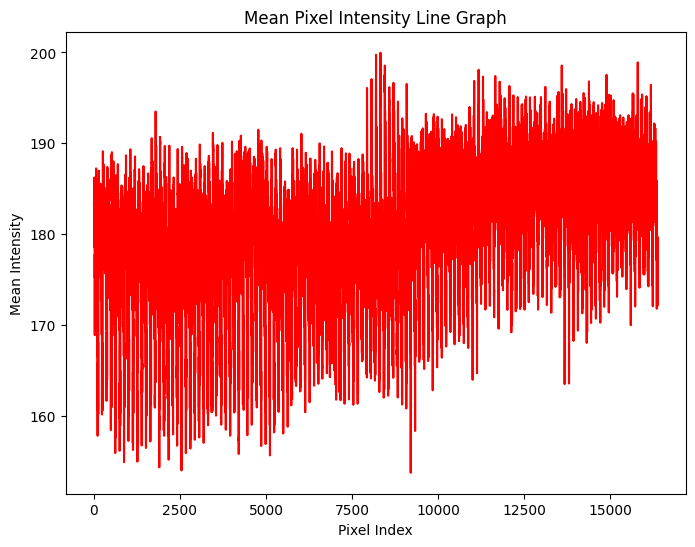

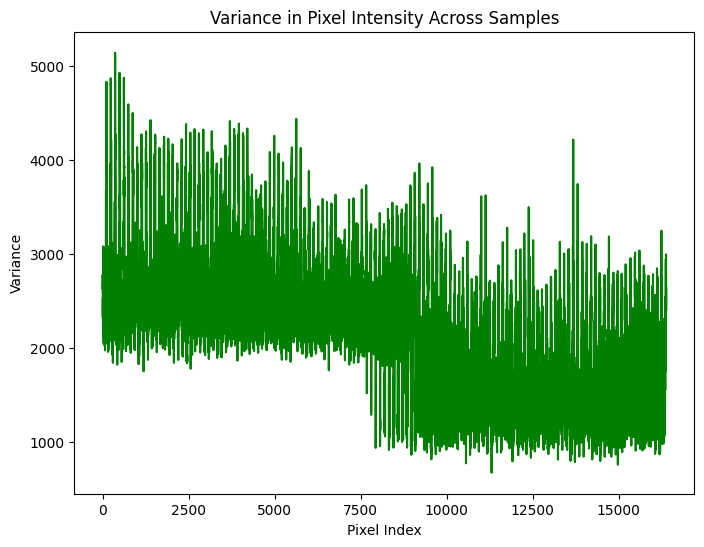

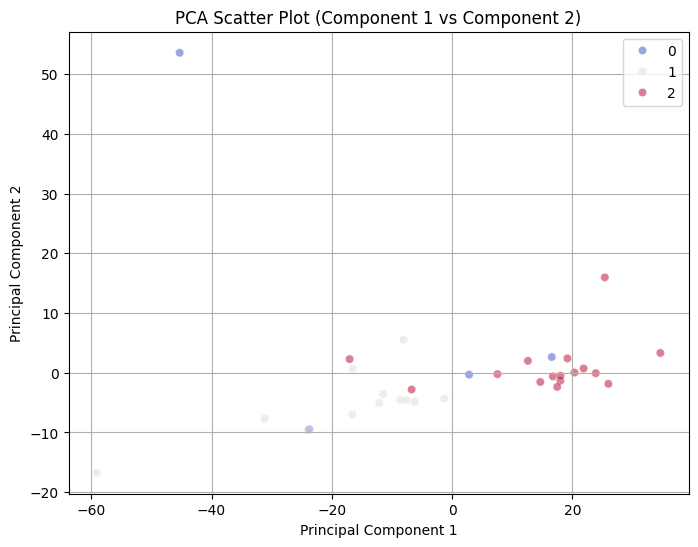

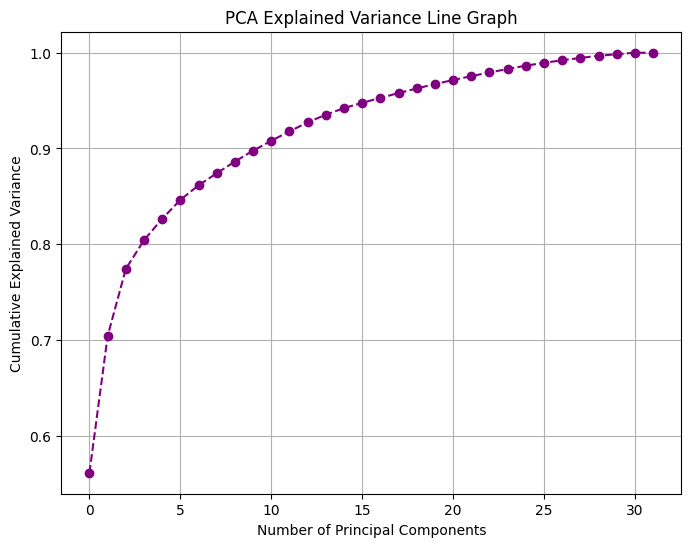

In [14]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Set path and parameters
base_dir = "/content/unzipped_folder"
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# ✅ Remove corrupted images
def remove_corrupted_images(directory):
    for root, _, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                img = Image.open(fpath)
                img.verify()
            except (UnidentifiedImageError, IOError, SyntaxError):
                os.remove(fpath)

remove_corrupted_images(base_dir)

# Image generator with augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2
)

# Load data
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    base_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=True
)

# Extract batch
X_train, y_train = next(train_generator)
X_val, y_val = next(val_generator)

# Image Preprocessing Function
def preprocess_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    normalized = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
    hist_eq = cv2.equalizeHist(normalized)
    adaptive_thresh = cv2.adaptiveThreshold(hist_eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    pca = PCA(n_components=0.95)
    img_pca = pca.fit_transform(hist_eq)
    edges = cv2.Canny(hist_eq, 50, 150)
    denoised = cv2.fastNlMeansDenoising(hist_eq, None, 10, 7, 21)
    return {
        "Normalized": normalized,
        "Histogram Equalization": hist_eq,
        "Adaptive Thresholding": adaptive_thresh,
        "PCA": img_pca,
        "Edge Detection": edges,
        "Denoised": denoised
    }

# Preprocess all images
X_train_processed, y_train_labels = [], []
X_val_processed, y_val_labels = [], []

for i in range(len(X_train)):
    processed = preprocess_image((X_train[i] * 255).astype(np.uint8))
    X_train_processed.append(processed["Normalized"].flatten())
    y_train_labels.append(y_train[i])

for i in range(len(X_val)):
    processed = preprocess_image((X_val[i] * 255).astype(np.uint8))
    X_val_processed.append(processed["Normalized"].flatten())
    y_val_labels.append(y_val[i])

X_train_processed = np.array(X_train_processed)
X_val_processed = np.array(X_val_processed)

# Normalize features
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

# Encode labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_labels)
y_val_encoded = label_encoder.transform(y_val_labels)

# 🔹 Plot histograms of different preprocessing techniques
plt.figure(figsize=(15, 6))
for i, (key, img) in enumerate(preprocess_image((X_train[0] * 255).astype(np.uint8)).items()):
    plt.subplot(2, 3, i+1)
    sns.histplot(img.ravel(), bins=50, kde=True, color="blue")
    plt.title(f"{key} Histogram")
plt.tight_layout()
plt.show()

# 🔹 Mean pixel intensity line plot
plt.figure(figsize=(8, 6))
mean_pixel_intensity = np.mean(X_train_processed, axis=0)
plt.plot(mean_pixel_intensity, color='red')
plt.title("Mean Pixel Intensity Line Graph")
plt.xlabel("Pixel Index")
plt.ylabel("Mean Intensity")
plt.show()

# 🔹 Pixel variance plot
plt.figure(figsize=(8, 6))
pixel_variance = np.var(X_train_processed, axis=0)
plt.plot(pixel_variance, color='green')
plt.title("Variance in Pixel Intensity Across Samples")
plt.xlabel("Pixel Index")
plt.ylabel("Variance")
plt.show()

# PCA Scatter Plot using Scaled Data (Component 1 vs Component 2)
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_transformed[:, 0], y=pca_transformed[:, 1], hue=y_train_encoded, palette="coolwarm", alpha=0.5)
plt.title("PCA Scatter Plot (Component 1 vs Component 2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()

# 🔹 PCA Explained Variance Line Graph
pca_full = PCA().fit(X_train_scaled)
plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='--', color='purple')
plt.title("PCA Explained Variance Line Graph")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()
